Loading dataset: AGRI DATASET.csv

--- Dataset Overview ---
Shape: 16146 rows, 80 columns
   Dist Code  Year  State Code    State Name Dist Name  RICE AREA (1000 ha)  \
0          1  1966          14  Chhattisgarh      Durg                548.0   
1          1  1967          14  Chhattisgarh      Durg                547.0   
2          1  1968          14  Chhattisgarh      Durg                556.3   
3          1  1969          14  Chhattisgarh      Durg                563.4   
4          1  1970          14  Chhattisgarh      Durg                571.6   

   RICE PRODUCTION (1000 tons)  RICE YIELD (Kg per ha)  WHEAT AREA (1000 ha)  \
0                        185.0                  337.59                  44.0   
1                        409.0                  747.71                  50.0   
2                        468.0                  841.27                  53.7   
3                        400.8                  711.40                  49.4   
4                        473.6     

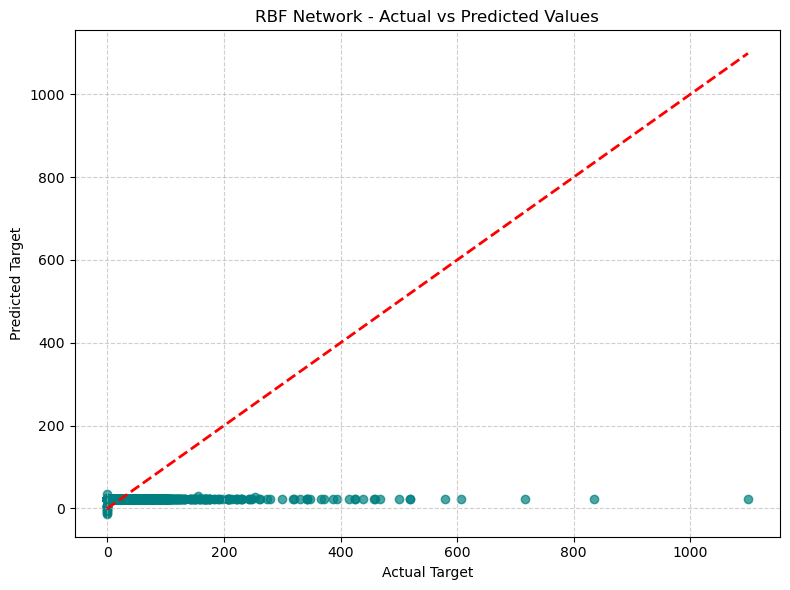

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_squared_error, r2_score, mean_absolute_error
)

# ==========================================
# 1. RBF NETWORK IMPLEMENTATION FROM SCRATCH
# ==========================================
class RBFNetwork:
    """
    Radial Basis Function Network supporting both Regression and Classification.
    """
    def __init__(self, n_centers=10, gamma=None, ridge_alpha=1e-6, task='auto'):
        self.n_centers = n_centers
        self.gamma = gamma
        self.ridge_alpha = ridge_alpha
        self.task = task
        self.centers = None
        self.weights = None
        self.label_encoder = None

    def _compute_rbf_matrix(self, X):
        """Computes Gaussian RBF activation matrix Phi."""
        # Pairwise Euclidean distances squared: ||x_i - c_j||^2
        dists_sq = np.sum((X[:, np.newaxis, :] - self.centers[np.newaxis, :, :]) ** 2, axis=2)
        return np.exp(-self.gamma * dists_sq)

    def fit(self, X, y):
        # Determine Task Type (Classification or Regression)
        if self.task == 'auto':
            if y.dtype == 'object' or len(np.unique(y)) < 15:
                self.task = 'classification'
            else:
                self.task = 'regression'

        # Target Encoding
        if self.task == 'classification':
            self.label_encoder = LabelEncoder()
            y_encoded = self.label_encoder.fit_transform(y)
            n_classes = len(np.unique(y_encoded))
            # One-hot encode targets for output layer optimization
            Y_target = np.eye(n_classes)[y_encoded]
        else:
            Y_target = y.reshape(-1, 1) if y.ndim == 1 else y

        # Step 1: Learn RBF Centers via K-Means
        kmeans = KMeans(n_clusters=self.n_centers, random_state=42, n_init=10)
        kmeans.fit(X)
        self.centers = kmeans.cluster_centers_

        # Step 2: Compute Gamma (Spread) if not provided
        if self.gamma is None:
            # Calculate mean distance between cluster centers
            center_dists = np.linalg.norm(self.centers[:, np.newaxis] - self.centers, axis=2)
            max_dist = np.max(center_dists)
            sigma = max_dist / np.sqrt(2 * self.n_centers)
            self.gamma = 1.0 / (2 * (sigma ** 2) + 1e-8)

        # Step 3: Compute Hidden Layer Activation Matrix Phi
        Phi = self._compute_rbf_matrix(X)

        # Add Bias term column of 1s
        Phi_bias = np.hstack([np.ones((Phi.shape[0], 1)), Phi])

        # Step 4: Analytical Weight Optimization (Closed-Form Ridge Least Squares)
        # W = (Phi^T * Phi + alpha * I)^(-1) * Phi^T * Y
        reg_matrix = self.ridge_alpha * np.eye(Phi_bias.shape[1])
        self.weights = np.linalg.pinv(Phi_bias.T @ Phi_bias + reg_matrix) @ Phi_bias.T @ Y_target

        return self

    def predict(self, X):
        Phi = self._compute_rbf_matrix(X)
        Phi_bias = np.hstack([np.ones((Phi.shape[0], 1)), Phi])
        raw_out = Phi_bias @ self.weights

        if self.task == 'classification':
            class_indices = np.argmax(raw_out, axis=1)
            return self.label_encoder.inverse_transform(class_indices)
        else:
            return raw_out.ravel()


# ==========================================
# 2. DATA PIPELINE & AUTOMATED PREPROCESSING
# ==========================================
def load_and_preprocess_data(file_path):
    print(f"Loading dataset: {file_path}")
    df = pd.read_csv(file_path)
    
    print("\n--- Dataset Overview ---")
    print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
    print(df.head())

    # Handle Missing Values
    if df.isnull().sum().sum() > 0:
        print("\nHandling missing values...")
        df.ffill(inplace=True)
        df.bfill(inplace=True)

    # Assume the last column is the Target Variable
    X = df.iloc[:, :-1].copy()
    y = df.iloc[:, -1].copy()

    # Preprocess Feature Columns
    num_cols = X.select_dtypes(include=['float64', 'int64']).columns
    cat_cols = X.select_dtypes(include=['object', 'category']).columns

    if len(cat_cols) > 0:
        X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

    # Scale Numerical Features (Crucial for RBF Euclidean distance calculation)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X_scaled, y.values, list(X.columns)


# ==========================================
# 3. MODEL TRAINING & EVALUATION PIPELINE
# ==========================================
def main():
    file_path = "AGRI DATASET.csv"
    
    try:
        X, y, feature_names = load_and_preprocess_data(file_path)
    except FileNotFoundError:
        print(f"Error: Could not locate '{file_path}'. Ensuring fallback synthetic data...")
        # Synthetic Agricultural Data fallback for standalone execution testing
        np.random.seed(42)
        N = 500
        N_val = np.random.uniform(10, 140, N)
        P_val = np.random.uniform(5, 145, N)
        K_val = np.random.uniform(15, 205, N)
        temp = np.random.uniform(8, 45, N)
        ph = np.random.uniform(3.5, 9.9, N)
        rain = np.random.uniform(20, 300, N)
        crops = np.random.choice(['Rice', 'Maize', 'Chickpea', 'Cotton'], size=N)
        
        df = pd.DataFrame({'N': N_val, 'P': P_val, 'K': K_val, 'temperature': temp, 'ph': ph, 'rainfall': rain, 'label': crops})
        X = StandardScaler().fit_transform(df.iloc[:, :-1])
        y = df['label'].values

    # Train / Test Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Instantiate RBF Network
    # Use ~10-25% of training samples as center count for optimal fit
    n_centers = min(30, max(5, int(len(X_train) * 0.15)))
    rbf_model = RBFNetwork(n_centers=n_centers, ridge_alpha=1e-4)

    print(f"\nTraining RBF Network with {n_centers} Radial Centers...")
    rbf_model.fit(X_train, y_train)

    # Make Predictions
    y_pred = rbf_model.predict(X_test)

    # Dynamic Evaluation Output based on Task
    print("\n==========================================")
    print(f"       RBF NETWORK PERFORMANCE ({rbf_model.task.upper()})")
    print("==========================================")

    if rbf_model.task == 'classification':
        acc = accuracy_score(y_test, y_pred)
        print(f"Accuracy: {acc * 100:.2f}%\n")
        print("Classification Report:")
        print(classification_report(y_test, y_pred))

        # Visualization: Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', 
                    xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
        plt.title('RBF Network - Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.tight_layout()
        plt.show()

    else:
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print(f"Mean Squared Error (MSE): {mse:.4f}")
        print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
        print(f"Mean Absolute Error (MAE): {mae:.4f}")
        print(f"R^2 Variance Score: {r2:.4f}")

        # Visualization: Actual vs Predicted
        plt.figure(figsize=(8, 6))
        plt.scatter(y_test, y_pred, alpha=0.7, color='teal')
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
        plt.title('RBF Network - Actual vs Predicted Values')
        plt.xlabel('Actual Target')
        plt.ylabel('Predicted Target')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    main()